In [180]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

plt.style.use("matlab.mplstyle")

In [181]:
UR = np.genfromtxt(r"C:\Users\z003zh2j\Desktop\PLOT\eqn\e-ur.csv", delimiter=',', skip_header=0)

t = UR[: , 0]/1e6
u = UR[: , 1]/50
r = UR[: , 2]/1e3

In [182]:
ABR = np.genfromtxt(r"S:\1.FILE\ern\greiner-ern-abr-totak-ko.csv", delimiter=',', skip_header=0)

tt = ABR[: , 0]/1e6
a = ABR[: , 1]/1e3
b = ABR[: , 2]/1e3
rr = ABR[: , 3]/1e3

In [183]:
CDR = np.genfromtxt(r"S:\1.FILE\ern\greiner-ern-cdr-totak-ko.csv", delimiter=',', skip_header=0)

ttt = CDR[: , 0]/1e6
c = CDR[: , 1]/1e3
d = CDR[: , 2]/1e3
rrr = CDR[: , 3]/1e3

In [184]:
try:
  def pnej(seznam):
    points = find_peaks(seznam, distance=100000)
    i = 0
    N = []
    for n in points[0]:
        if seznam[n] > 0:
            if i <= 0:
                i += 1
                N.append(n)
    indexy = N[0]
    return indexy                
except IndexError:
  R, RR, RRR = 50,100,100

R = t[pnej(r)]
RR = tt[pnej(rr)]
RRR = ttt[pnej(rrr)]

def timel(leng,okno,jaky):
    if jaky == "R":
        jaky = R
    elif jaky == "RR":
        jaky = RR
    elif jaky == "RRR":
        jaky = RRR

    N1 = np.linspace(jaky-(-1 * ((leng-1) /2)) * okno , jaky-((leng-1) /2)* okno,leng)
    N2 = np.linspace(-1 * ((leng-1) /2) * okno , ((leng-1) /2) * okno,leng)
    N1 = N1.tolist()
    N1.sort()
    N2 = N2.tolist()
    N2 = ["%.2f" % member for member in N2]

    return(N1,N2)

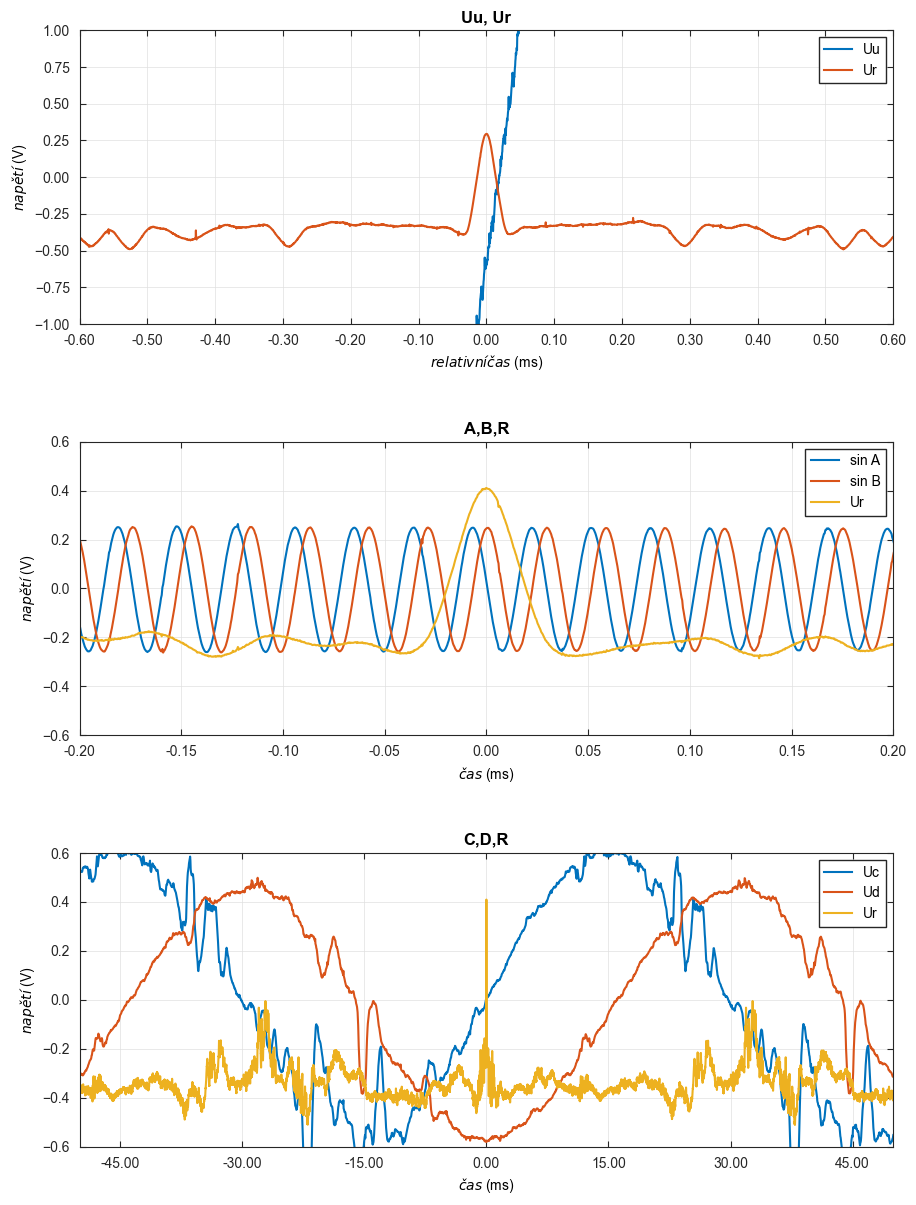

In [185]:
fig = plt.figure(figsize=(10.5, 14.5))

# Vytvoření mřížky (4 řádků, 1 sloupec)
gs = fig.add_gridspec(3, 1, hspace=0.4, wspace=0.3)

# 1. Horní graf
u_vyhl = savgol_filter(u, window_length=15, polyorder=2)
ax1 = fig.add_subplot(gs[0, 0])
N1 , N2 = timel(13,0.1,"R")
ax1.set_xticks(N1) 
ax1.set_xticklabels(N2)
ax1.plot(t, u_vyhl, label="Uu")
ax1.plot(t, r, label="Ur")
ax1.set_xlim(R-0.6, R+0.6)
ax1.set_ylim(-1, 1)
ax1.set_title('Uu, Ur')
ax1.legend(loc='upper right')
ax1.set_xlabel("$relativní čas$ (ms)")
ax1.set_ylabel("$napětí$ (V)")

# 2. Prostřední graf 
ax2 = fig.add_subplot(gs[1, 0])
N1 , N2 = timel(9,0.05,"RR")
ax2.set_xticks(N1) 
ax2.set_xticklabels(N2)
ax2.set_xlim(RR-0.2,RR+0.2)
ax2.set_ylim(-0.6, 0.6)
ax2.plot(tt, a, label="sin A")
ax2.plot(tt, b, label="sin B")
ax2.plot(tt, rr, label="Ur")
ax2.set_title("A,B,R")
ax2.legend(loc='upper right')
ax2.set_xlabel("$čas$ (ms)")
ax2.set_ylabel("$napětí$ (V)")

# 3. Velký spodní graf 
ax3 = fig.add_subplot(gs[2, 0])
rrr_vyhl = savgol_filter(rrr, window_length=15, polyorder=2)
N1 , N2 = timel(7,15,"RRR")
ax3.set_xticks(N1) 
ax3.set_xticklabels(N2)
ax3.set_xlim(RRR-50,RRR+50)
ax3.set_ylim(-0.6, 0.6)
#ax3.set_ylim(-1, 1)
ax3.plot(ttt[::100], c[::100], label="Uc")
ax3.plot(ttt[::100], d[::100], label="Ud")
ax3.plot(ttt, rrr_vyhl, label="Ur")
ax3.set_title("C,D,R")
ax3.legend(loc='upper right')
ax3.set_xlabel("$čas$ (ms)")
ax3.set_ylabel("$napětí$ (V)")

# # Zobrazení grafu
plt.show()

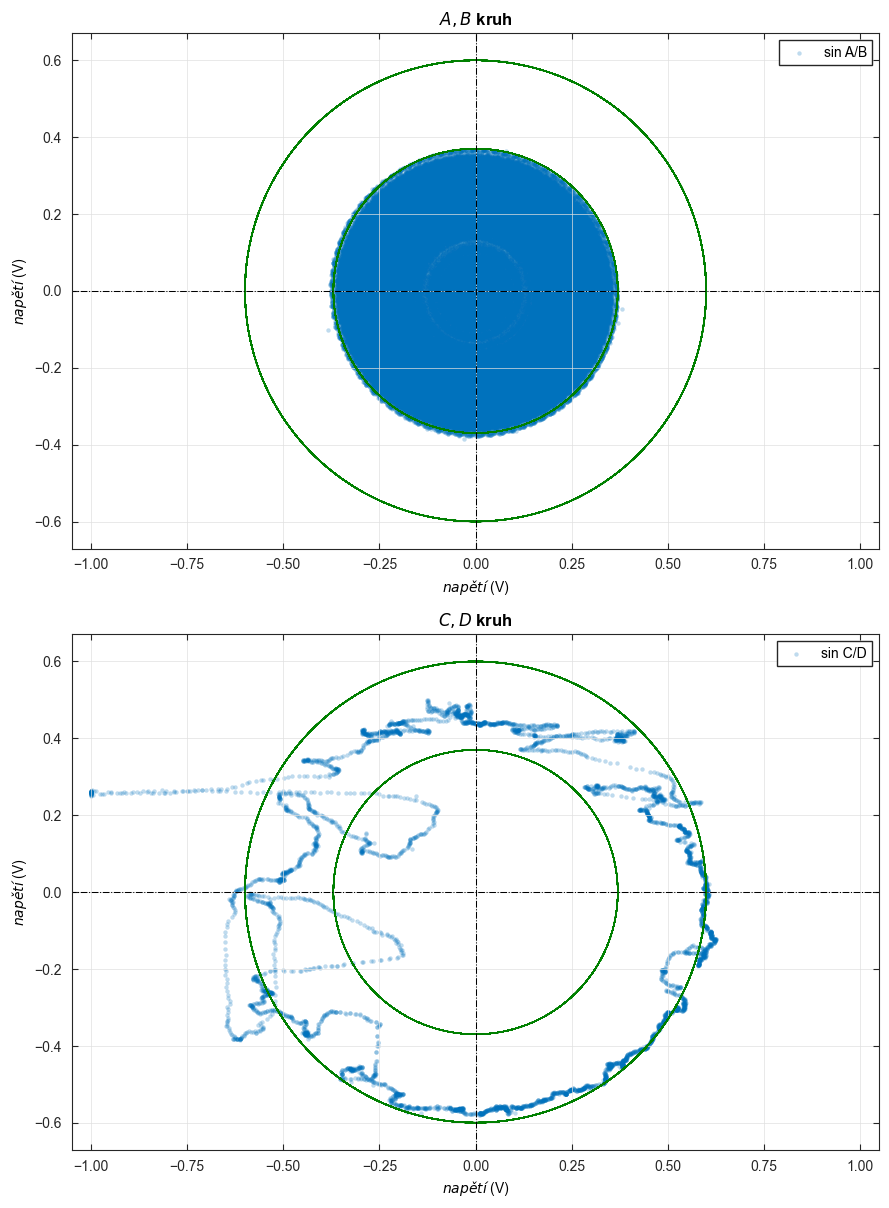

In [186]:
fig = plt.figure(figsize=(10.5, 14.5))

x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0

# Vytvoření mřížky (4 řádků, 1 sloupec)
gs = fig.add_gridspec(4, 1, hspace=0.4, wspace=0.3)

# 1. Horní graf
ax1 = fig.add_subplot(gs[0:2, 0])

ax1.plot(y, yy, lw=0.75, color='g')
ax1.plot(w, ww, lw=0.75, color='g')
ax1.scatter(a[0:len(a)//6], b[0:len(b)//6], linewidths=0.1, marker=".", alpha=0.25, label="sin A/B")
ax1.set_xlim(-1.05, 1.05)
ax1.set_ylim(-0.67, 0.67)
ax1.vlines(0, -0.67, 0.67, color='k', linestyles='-.', lw=0.75)
ax1.hlines(0, -1.2, 1.2, color='k', linestyles='-.', lw=0.75)
ax1.set_title("$A,B$ kruh")
ax1.legend(loc='upper right')
ax1.set_xlabel("$napětí$ (V)")
ax1.set_ylabel("$napětí$ (V)")
ax1.set_aspect('equal', adjustable='box')

# 2. Spodní graf

ax2 = fig.add_subplot(gs[2:4, 0])

ax2.plot(y, yy, lw=0.75, color='g')
ax2.plot(w, ww, lw=0.75, color='g')
ax2.scatter(c[0:len(c)//6][::100], d[0:len(d)//6][::100], linewidths=0.1, marker=".", alpha=0.25, label="sin C/D")
ax2.set_xlim(-1.05, 1.05)
ax2.set_ylim(-0.67, 0.67)
ax2.vlines(0, -0.67, 0.67, color='k', linestyles='-.', lw=0.75)
ax2.hlines(0, -1.2, 1.2, color='k', linestyles='-.', lw=0.75)
ax2.set_title("$C,D$ kruh")
ax2.legend(loc='upper right')
ax2.set_xlabel("$napětí$ (V)")
ax2.set_ylabel("$napětí$ (V)")
ax2.set_aspect('equal', adjustable='box')

# # Zobrazení grafu
plt.show()